In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import Sequential
from tensorflow.keras.losses import MeanSquaredError, BinaryCrossentropy
from tensorflow.keras.activations import sigmoid
from jupyter_utils_common import dlc
from jupyter_neurons_utils import plt_prob_1d, sigmoidnp, plt_linear, plt_logistic
plt.style.use("./deeplearning.mplstyle")

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

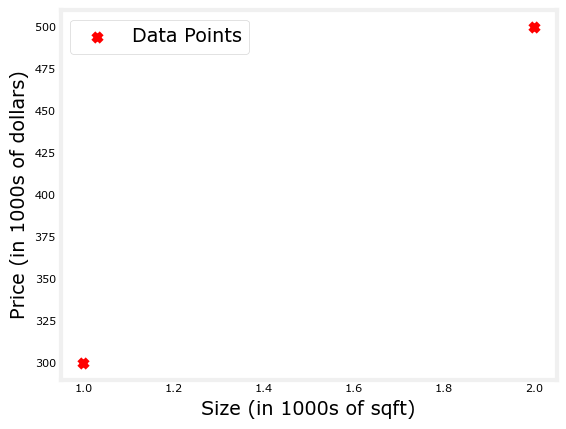

In [3]:
x_train = np.array([[1.0], [2.0]], dtype=np.float32)
y_train = np.array([[300.0], [500.0]], dtype=np.float32)

fig, ax = plt.subplots(1, 1)
ax.scatter(x_train, y_train, marker="x", c="r", label="Data Points")
ax.legend(fontsize="xx-large")
ax.set_ylabel("Price (in 1000s of dollars)", fontsize="xx-large")
ax.set_xlabel("Size (in 1000s of sqft)", fontsize="xx-large")
plt.show()

In [4]:
linear_layer = tf.keras.layers.Dense(units=1, activation="linear")

In [6]:
linear_layer.get_weights()

[]

In [8]:
a1 = linear_layer(x_train[0].reshape(1, 1))
print(a1)

tf.Tensor([[1.7108914]], shape=(1, 1), dtype=float32)


In [9]:
w, b = linear_layer.get_weights()
print(f"w = {w}, b = {b}")

w = [[1.7108914]], b = [0.]


In [11]:
set_w = np.array([[200.0]])
set_b = np.array([100.0])

linear_layer.set_weights([set_w, set_b])
print(linear_layer.get_weights())

[array([[200.]], dtype=float32), array([100.], dtype=float32)]


In [12]:
a1 = linear_layer(x_train[0].reshape(1, 1))
print(a1)

alin = np.dot(set_w, x_train[0].reshape(1, 1)) + set_b
print(alin)

tf.Tensor([[300.]], shape=(1, 1), dtype=float32)
[[300.]]


In [13]:
prediction_tf = linear_layer(x_train)
prediction_np = np.dot(x_train, set_w) + set_b

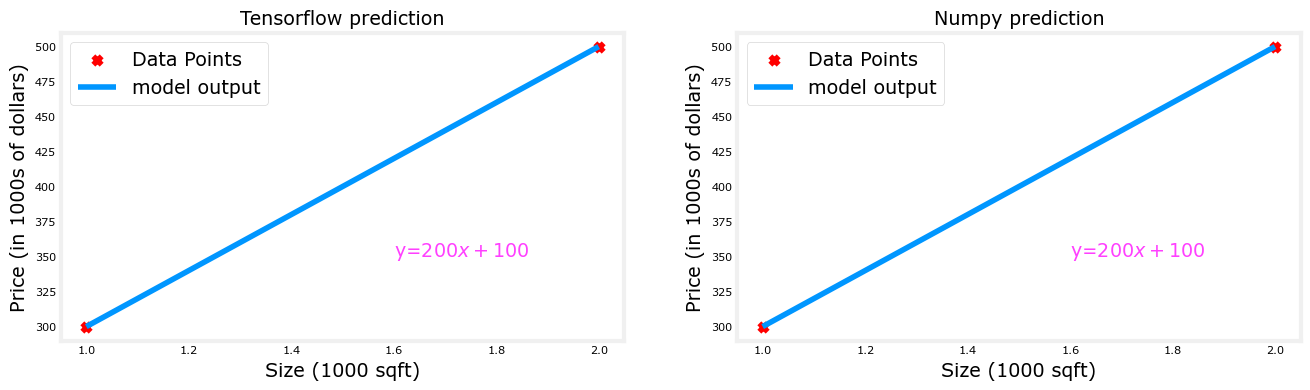

In [14]:
plt_linear(x_train, y_train, prediction_tf, prediction_np)

In [15]:
x_train = np.array([0, 1, 2, 3, 4, 5], dtype=np.float32).reshape(-1, 1)
y_train = np.array([0, 0, 0, 1, 1, 1], dtype=np.float32).reshape(-1, 1)

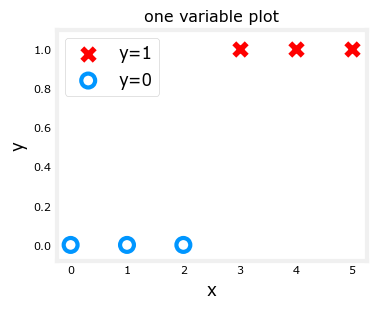

In [17]:
pos = y_train == 1
neg = y_train == 0

fig,ax = plt.subplots(1, 1, figsize=(4, 3))
ax.scatter(x_train[pos], y_train[pos], marker="x", s=80, c = "red", label="y=1")
ax.scatter(x_train[neg], y_train[neg], marker="o", s=100, label="y=0", facecolors="none", 
              edgecolors=dlc["dlblue"], lw=3)

ax.set_ylim(-0.08, 1.1)
ax.set_ylabel("y", fontsize=12)
ax.set_xlabel("x", fontsize=12)
ax.set_title("one variable plot")
ax.legend(fontsize=12)
plt.show()

In [18]:
model = Sequential(
    [
        tf.keras.layers.Dense(1, input_dim=1,  activation = "sigmoid", name="L1")
    ]
)

/Users/mikemao/.pyenv/versions/3.10.11/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
logistic_layer = model.get_layer("L1")
w, b = logistic_layer.get_weights()
print(w, b)
print(w.shape, b.shape)

[[-1.330513]] [0.]
(1, 1) (1,)


In [21]:
set_w = np.array([[2]])
set_b = np.array([-4.5])

logistic_layer.set_weights([set_w, set_b])
print(logistic_layer.get_weights())

[array([[2.]], dtype=float32), array([-4.5], dtype=float32)]


In [22]:
a1 = model.predict(x_train[0].reshape(1,1))
print(a1)
alog = sigmoidnp(np.dot(set_w, x_train[0].reshape(1, 1)) + set_b)
print(alog)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
[[0.01098694]]
[[0.01098694]]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s

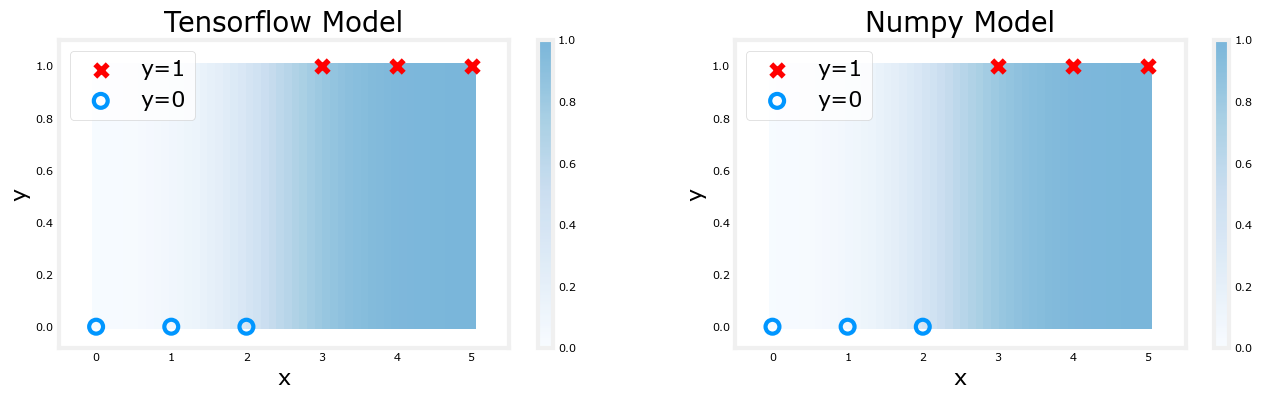

In [23]:
plt_logistic(x_train, y_train, model, set_w, set_b, pos, neg)